In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import random
from pathlib import Path
from ultralytics import YOLO

# Resolve paths whether the notebook is opened from the project root or notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
best_model_path = project_root / "best_960.pt"
dataset_dir = project_root / "data" / "GTSDB" / "dataset"
model = YOLO(best_model_path)

def predict_image_by_id(img_id, conf=0.25):
    """
    Takes an image ID (int), opens the corresponding PPM image, and runs inference.
    """
    # Format ID to 5 digits (e.g., 45 -> 00045.ppm)
    img_name = f"{img_id:05d}.ppm"
    img_path = dataset_dir / "images" / img_name

    if not img_path.exists():
        print(f"Error: Image {img_path} not found.")
        return

    # Decode the PPM first because Ultralytics does not accept .ppm as a file suffix.
    original_rgb = Image.open(img_path).convert("RGB")
    results = model.predict(source=original_rgb, conf=conf, imgsz=960)

    # Show the original and annotated image together in a single figure.

    for result in results:
        # result.plot() returns a BGR numpy array with boxes/labels drawn
        res_bgr = result.plot()
        res_rgb = cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        axes[0].imshow(original_rgb)
        axes[0].set_title(f"Original: {img_name}")
        axes[0].axis("off")

        axes[1].imshow(res_rgb)
        axes[1].set_title(f"Predictions: {img_name}")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


def predict_random_image_by_class(class_id, conf=0.25):
    """
    Selects a random image containing class_id according to gt.txt,
    then displays the original image and the model predictions.

    Returns the selected integer image ID.
    """
    try:
        class_id = int(class_id)
    except (TypeError, ValueError) as exc:
        raise ValueError("class_id must be an integer") from exc

    gt_path = project_root / "data" / "GTSDB" / "gt.txt"
    if not gt_path.exists():
        raise FileNotFoundError(f"Ground-truth file not found: {gt_path}")

    matching_image_ids = set()
    with gt_path.open("r", encoding="utf-8") as gt_file:
        for line in gt_file:
            fields = line.strip().split(";")
            if len(fields) == 6 and int(fields[5]) == class_id:
                matching_image_ids.add(int(Path(fields[0]).stem))

    if not matching_image_ids:
        raise ValueError(f"No image in gt.txt contains class {class_id}")

    image_id = random.choice(sorted(matching_image_ids))
    print(f"Selected image {image_id:05d}.ppm for class {class_id}")
    predict_image_by_id(image_id, conf=conf)
    return image_id

In [36]:
analysis = model.val(
    data=dataset_dir / "data.yaml",
    split="val",       # or "test"
    imgsz=960,
    batch=8,
    device="cpu",
    plots=True,
    visualize=True,
    project="model_test_results",
    name="error_analysis_960",
    exist_ok=True,
)

Ultralytics 8.4.118 🚀 Python-3.12.3 torch-2.13.0+cpu CPU (AMD Ryzen 5 PRO 4650U with Radeon Graphics)
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: [34m[1mval: [0mError loading data from /home/veselin/Documents/Programiranje/Autonomous Driving/Computer vision/traffic-sign-detection/data/GTSDB/dataset/val.txt
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

Selected image 00622.ppm for class 22

0: 576x960 1 slippery road, 1 cycles crossing, 110.6ms
Speed: 3.6ms preprocess, 110.6ms inference, 1.1ms postprocess per image at shape (1, 3, 576, 960)


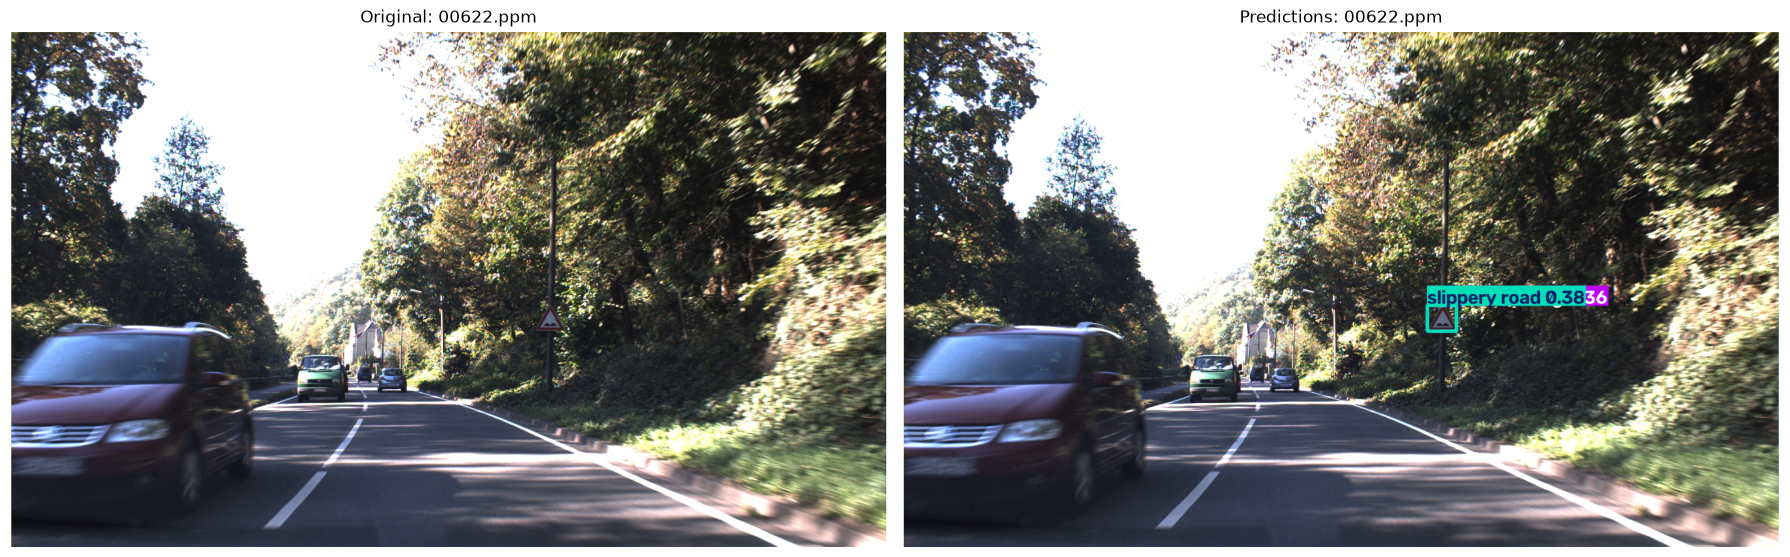

622

In [44]:
predict_random_image_by_class(22)